# 05 — Model Comparison

**Goal:** Train multiple models with default hyperparameters using the full feature set.  
Pick the best model family to carry into hyperparameter tuning.

> ✅ Only **train** data. Each model gets its own MLflow run.

**Models:**
- Ridge (baseline reference)
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM

**CV Strategy:** `TimeSeriesSplit(n_splits=5, gap=24)` — never KFold on time series.

In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import json
import time
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed: pip install xgboost')

try:
    from lightgbm import LGBMRegressor
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('LightGBM not installed: pip install lightgbm')

PROCESSED_PATH    = '../data/processed/'
MLFLOW_EXPERIMENT = 'energy-demand-prediction'
TARGET            = 'total load actual'
RANDOM_STATE      = 42
TSCV              = TimeSeriesSplit(n_splits=5, gap=24)

d:\my_projects\Energy_demand_predictor\energy_demand\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LightGBM not installed: pip install lightgbm


## 1. Load Data

In [2]:
train_raw = pd.read_csv(PROCESSED_PATH + 'train.csv')
train_raw['time'] = pd.to_datetime(train_raw['time'], utc=True)

with open(PROCESSED_PATH + 'feature_config.json') as f:
    config = json.load(f)

ALL_FEATURES = config['all_features']
print(f'Train raw: {train_raw.shape}  |  Features: {len(ALL_FEATURES)}')

Train raw: (24544, 32)  |  Features: 40


## 2. Feature Transformer (from notebook 03)

In [3]:
class EnergyFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, lag_hours=None, add_cyclical=True):
        self.lag_hours    = lag_hours or [1, 24, 48, 168, 336]
        self.add_cyclical = add_cyclical
    def fit(self, X, y=None): return self
    def transform(self, X):
        df = X.copy()
        df['time'] = pd.to_datetime(df['time'], utc=True)
        df = df.sort_values('time').reset_index(drop=True)
        df = self._cal(df); df = self._cyc(df) if self.add_cyclical else df
        df = self._lag(df); df = self._roll(df); df = self._weather(df)
        return df.dropna().reset_index(drop=True)
    def _cal(self, df):
        t=df['time']; df['hour']=t.dt.hour; df['dow']=t.dt.dayofweek
        df['month']=t.dt.month; df['day_of_year']=t.dt.dayofyear
        df['week_of_year']=t.dt.isocalendar().week.astype(int)
        df['quarter']=t.dt.quarter; df['is_weekend']=(t.dt.dayofweek>=5).astype(int)
        df['season']=df['month'].map({12:3,1:3,2:3,3:0,4:0,5:0,6:1,7:1,8:1,9:2,10:2,11:2})
        try:
            import holidays; es=holidays.Spain(years=range(2015,2020))
            df['is_holiday']=t.dt.date.astype(str).map(lambda d:1 if d in [str(h) for h in es] else 0)
        except: df['is_holiday']=0
        return df
    def _cyc(self, df):
        df['hour_sin']=np.sin(2*np.pi*df['hour']/24); df['hour_cos']=np.cos(2*np.pi*df['hour']/24)
        df['dow_sin']=np.sin(2*np.pi*df['dow']/7);   df['dow_cos']=np.cos(2*np.pi*df['dow']/7)
        df['month_sin']=np.sin(2*np.pi*df['month']/12); df['month_cos']=np.cos(2*np.pi*df['month']/12)
        df['doy_sin']=np.sin(2*np.pi*df['day_of_year']/365); df['doy_cos']=np.cos(2*np.pi*df['day_of_year']/365)
        return df
    def _lag(self, df):
        for lag in self.lag_hours: df[f'lag_{lag}h']=df[TARGET].shift(lag)
        return df
    def _roll(self, df):
        s=df[TARGET].shift(1)
        df['rolling_mean_24h']=s.rolling(24,min_periods=12).mean()
        df['rolling_mean_168h']=s.rolling(168,min_periods=84).mean()
        df['rolling_std_24h']=s.rolling(24,min_periods=12).std()
        df['rolling_max_24h']=s.rolling(24,min_periods=12).max()
        df['rolling_min_24h']=s.rolling(24,min_periods=12).min()
        return df
    def _weather(self, df):
        df['temp_squared']=df['temp']**2; df['is_cold']=(df['temp']<280).astype(int)
        df['is_hot']=(df['temp']>298).astype(int); df['temp_humidity']=df['temp']*df['humidity']/100
        df['is_raining']=(df['rain_1h']>0).astype(int); df['wind_chill']=df['wind_speed']*(1-df['temp']/310)
        return df

# Apply feature engineering
fe = EnergyFeatureTransformer()
train_fe = fe.fit_transform(train_raw)
X_train = train_fe[ALL_FEATURES]
y_train = train_fe[TARGET]

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')

X_train: (24208, 40)  |  y_train: (24208,)


## 3. Define Models

In [4]:
models = {
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=100, random_state=RANDOM_STATE),
}

if HAS_XGB:
    models['XGBoost'] = XGBRegressor(
        n_estimators=100, random_state=RANDOM_STATE,
        verbosity=0, n_jobs=-1)

if HAS_LGB:
    models['LightGBM'] = LGBMRegressor(
        n_estimators=100, random_state=RANDOM_STATE,
        verbose=-1, n_jobs=-1)

print(f'Models to compare: {list(models.keys())}')

Models to compare: ['Ridge', 'RandomForest', 'GradientBoosting', 'XGBoost']


## 4. Run All Models — Each in Its Own MLflow Run

In [5]:
mlflow.set_experiment(MLFLOW_EXPERIMENT)
results = []

for model_name, model in models.items():
    print(f'\nTraining {model_name}...')
    t0 = time.time()

    with mlflow.start_run(run_name=f'compare_{model_name}'):

        # Pipeline: scaler only needed for Ridge (tree models are scale-invariant)
        if model_name == 'Ridge':
            pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
        else:
            pipeline = Pipeline([('model', model)])

        # ── CV on train set (TimeSeriesSplit — not KFold!) ──
        cv_rmse = -cross_val_score(pipeline, X_train, y_train, cv=TSCV,
                                    scoring='neg_root_mean_squared_error')
        cv_mae  = -cross_val_score(pipeline, X_train, y_train, cv=TSCV,
                                    scoring='neg_mean_absolute_error')
        cv_r2   =  cross_val_score(pipeline, X_train, y_train, cv=TSCV,
                                    scoring='r2')

        # ── Train score ──
        pipeline.fit(X_train, y_train)
        y_pred_train = pipeline.predict(X_train)
        train_rmse   = np.sqrt(mean_squared_error(y_train, y_pred_train))
        train_r2     = r2_score(y_train, y_pred_train)
        overfit_gap  = train_r2 - cv_r2.mean()
        elapsed      = time.time() - t0

        # ── Log to MLflow ──
        mlflow.log_param('model_type',      model_name)
        mlflow.log_param('default_params',  True)
        mlflow.log_param('n_features',      X_train.shape[1])
        mlflow.log_param('cv_strategy',     'TimeSeriesSplit n=5 gap=24')
        mlflow.log_metric('cv_rmse_mean',   cv_rmse.mean())
        mlflow.log_metric('cv_rmse_std',    cv_rmse.std())
        mlflow.log_metric('cv_mae_mean',    cv_mae.mean())
        mlflow.log_metric('cv_r2_mean',     cv_r2.mean())
        mlflow.log_metric('cv_r2_std',      cv_r2.std())
        mlflow.log_metric('train_rmse',     train_rmse)
        mlflow.log_metric('train_r2',       train_r2)
        mlflow.log_metric('overfit_gap_r2', overfit_gap)
        mlflow.log_metric('training_time_s',elapsed)
        mlflow.sklearn.log_model(pipeline, artifact_path='model')

        results.append({
            'Model':         model_name,
            'CV RMSE':       round(cv_rmse.mean(), 2),
            'CV RMSE std':   round(cv_rmse.std(), 2),
            'CV R²':         round(cv_r2.mean(), 4),
            'Train R²':      round(train_r2, 4),
            'Overfit Gap':   round(overfit_gap, 4),
            'Time (s)':      round(elapsed, 1),
        })

        print(f'  CV RMSE: {cv_rmse.mean():>8,.2f} ± {cv_rmse.std():.2f} MW  |'
              f'  CV R²: {cv_r2.mean():.4f}  |  Gap: {overfit_gap:.4f}  |  {elapsed:.1f}s  ✅')


Training Ridge...


2026/03/08 10:02:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/08 10:02:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  CV RMSE:   910.97 ± 984.81 MW  |  CV R²: 0.9144  |  Gap: 0.0760  |  1.1s  ✅

Training RandomForest...


2026/03/08 10:05:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/08 10:05:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  CV RMSE:   432.81 ± 41.90 MW  |  CV R²: 0.9906  |  Gap: 0.0084  |  158.3s  ✅

Training GradientBoosting...


2026/03/08 10:08:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/08 10:08:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  CV RMSE:   430.54 ± 49.29 MW  |  CV R²: 0.9907  |  Gap: 0.0015  |  194.8s  ✅

Training XGBoost...


2026/03/08 10:09:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/08 10:09:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  CV RMSE:   451.07 ± 60.24 MW  |  CV R²: 0.9898  |  Gap: 0.0085  |  12.0s  ✅


## 5. Comparison Table

In [6]:
results_df = pd.DataFrame(results).sort_values('CV RMSE')
results_df = results_df.reset_index(drop=True)

print('MODEL COMPARISON RESULTS (sorted by CV RMSE — lower is better):')
print(results_df.to_string(index=False))
print()
best = results_df.iloc[0]
print(f'🏆 Winner: {best["Model"]}')
print(f'   CV RMSE: {best["CV RMSE"]:,.2f} MW  |  CV R²: {best["CV R²"]:.4f}')

MODEL COMPARISON RESULTS (sorted by CV RMSE — lower is better):
           Model  CV RMSE  CV RMSE std  CV R²  Train R²  Overfit Gap  Time (s)
GradientBoosting   430.54        49.29 0.9907    0.9922       0.0015     194.8
    RandomForest   432.81        41.90 0.9906    0.9990       0.0084     158.3
         XGBoost   451.07        60.24 0.9898    0.9982       0.0085      12.0
           Ridge   910.97       984.81 0.9144    0.9904       0.0760       1.1

🏆 Winner: GradientBoosting
   CV RMSE: 430.54 MW  |  CV R²: 0.9907


## 6. Visualizations

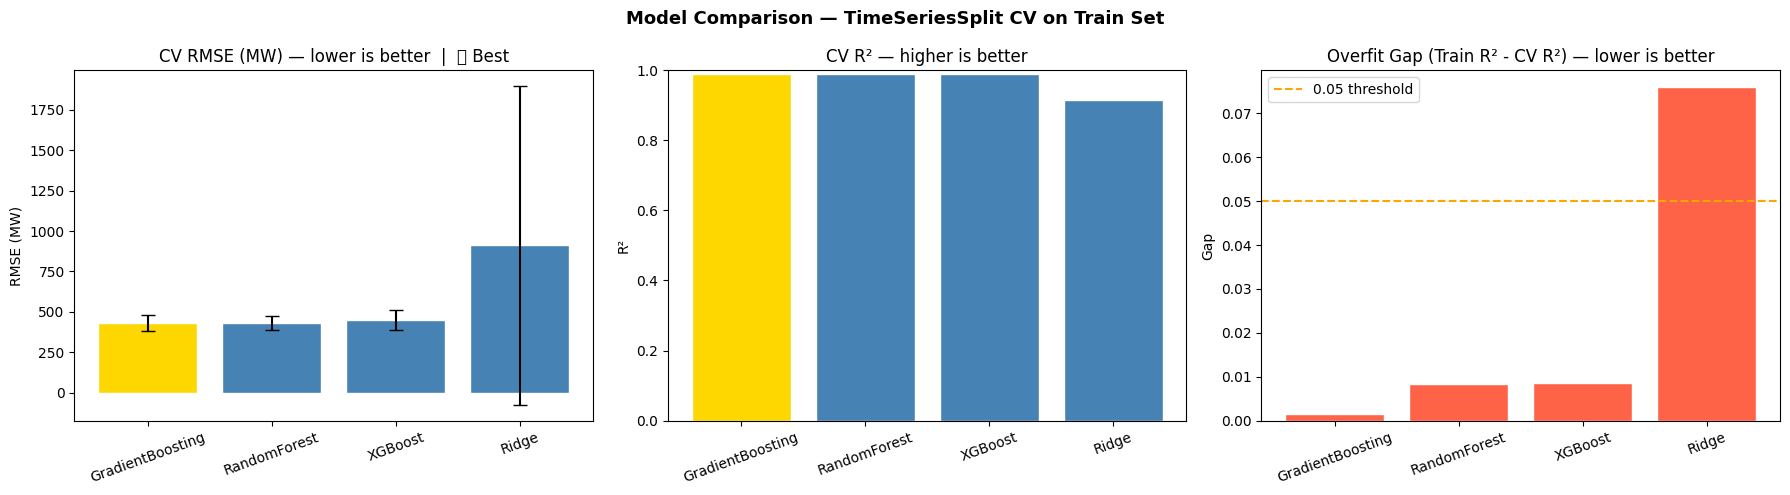

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names  = results_df['Model']
best_name    = results_df.iloc[0]['Model']
colors       = ['gold' if m == best_name else 'steelblue' for m in model_names]

# CV RMSE
bars = axes[0].bar(model_names, results_df['CV RMSE'], color=colors, edgecolor='white')
axes[0].errorbar(model_names, results_df['CV RMSE'],
                  yerr=results_df['CV RMSE std'], fmt='none', color='black', capsize=5)
axes[0].set_title('CV RMSE (MW) — lower is better  |  🥇 Best')
axes[0].set_ylabel('RMSE (MW)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20)

# CV R²
axes[1].bar(model_names, results_df['CV R²'], color=colors, edgecolor='white')
axes[1].set_title('CV R² — higher is better')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20)

# Overfitting gap
axes[2].bar(model_names, results_df['Overfit Gap'], color='tomato', edgecolor='white')
axes[2].axhline(y=0.05, color='orange', linestyle='--', label='0.05 threshold')
axes[2].set_title('Overfit Gap (Train R² - CV R²) — lower is better')
axes[2].set_ylabel('Gap')
axes[2].legend()
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=20)

plt.suptitle('Model Comparison — TimeSeriesSplit CV on Train Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

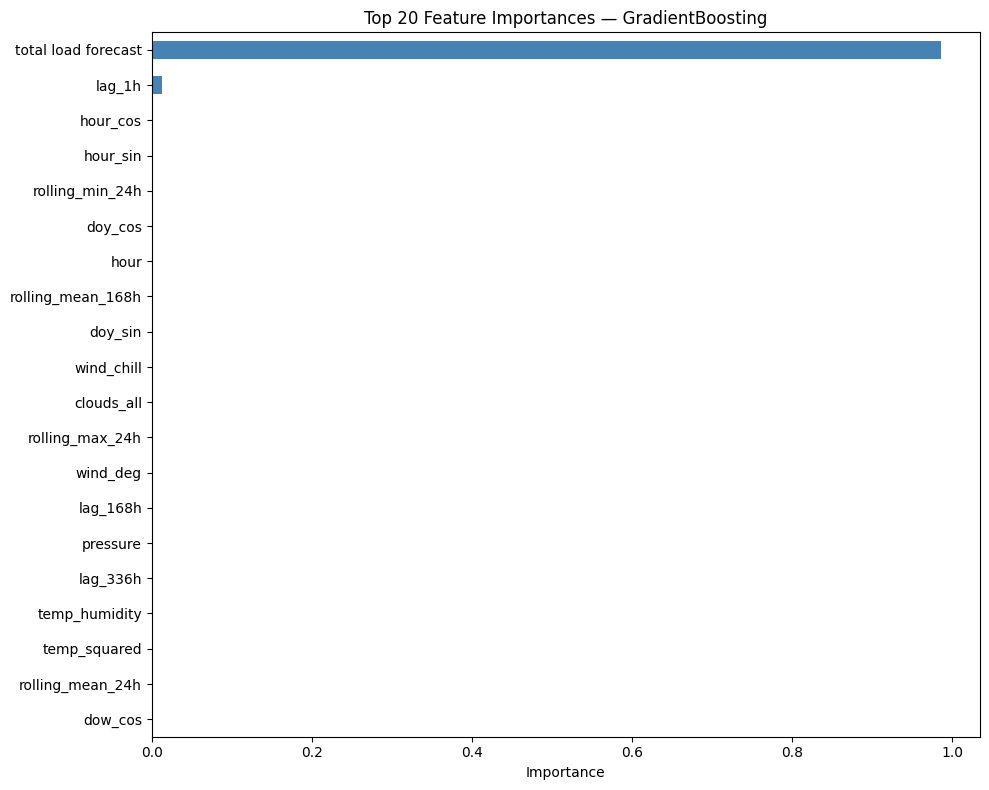

Top 5 features (confirms lag_24h and lag_168h dominate):
rolling_min_24h        0.0002
hour_sin               0.0004
hour_cos               0.0006
lag_1h                 0.0123
total load forecast    0.9856


In [8]:
# Feature importance for tree models
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    # Re-fit to get importances
    if best_model_name == 'Ridge':
        pipe = Pipeline([('scaler', StandardScaler()), ('model', best_model)])
    else:
        pipe = Pipeline([('model', best_model)])
    pipe.fit(X_train, y_train)

    importances = pd.Series(
        best_model.feature_importances_,
        index=ALL_FEATURES
    ).sort_values(ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 20 Feature Importances — {best_model_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    print('Top 5 features (confirms lag_24h and lag_168h dominate):')
    print(importances.tail(5).round(4).to_string())

## 7. Final Decision

In [9]:
best_model_name = results_df.iloc[0]['Model']
print(f'DECISION: Best model family → {best_model_name}')
print()
print('Criteria applied:')
print('  1. Lowest CV RMSE = best generalization')
print('  2. Acceptable overfit gap (< 0.05 R²)')
print('  3. Reasonable training time')
print()
print(f'→ Proceed to notebook 06 with: {best_model_name}')

# Save best model name for notebook 06
with open(PROCESSED_PATH + 'best_model.txt', 'w') as f:
    f.write(best_model_name)

print(f'✅ Saved to {PROCESSED_PATH}best_model.txt')

DECISION: Best model family → GradientBoosting

Criteria applied:
  1. Lowest CV RMSE = best generalization
  2. Acceptable overfit gap (< 0.05 R²)
  3. Reasonable training time

→ Proceed to notebook 06 with: GradientBoosting
✅ Saved to ../data/processed/best_model.txt
